In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Import your engine (make sure transport_analytics.py is in the same folder)
from train_bike_analysis import transport_analytics as ta

# Professional Plotting Style
sns.set_theme(style="whitegrid", context="talk")
%matplotlib inline

In [5]:
# FILE PATHS
FILE_BIKE_DATA = '../data/nextbike_data_VSB_Vaclavik.xlsx'

# CONFIGURATION
NETWORKS = {
    'Ostrava_Svinov': {
        'file_trains': 'data/Pohyby_Svinov.xlsx',
        'sheet_rentals': 'Vypujcky_Ostrava',
        'train_station': 'Ostrava-Svinov',
        'bike_stations': ['SV-Svinov nádraží *(navíc 15min na odjezd)'],
        'params': {'pulse_arr': 25, 'pulse_dep': 40, 'peak_arr': 4, 'peak_dep': 12, 'rush_am': 1.8, 'rush_pm': 1.8}
    },
    'Brno_Main': {
        'file_trains': 'data/Pohyby_Brno.xlsx',
        'sheet_rentals': 'Vypujcky_Brno',
        'train_station': 'Brno hl.n.',
        'bike_stations': ['Hlavní nádraží - Hlavní vstup', 'Hlavní nádraží - pošta', 'Bajkazyl 666'],
        'params': {'pulse_arr': 45, 'pulse_dep': 60, 'peak_arr': 10, 'peak_dep': 20, 'rush_am': 2.0, 'rush_pm': 2.0}
    },
    'Prerov': {
        'file_trains': 'data/Pohyby_Prerov.xlsx',
        'sheet_rentals': 'Vypujcky_Prerov',
        'train_station': 'Přerov os.n.',
        'bike_stations': ['Nádraží'],
        'params': {'pulse_arr': 15, 'pulse_dep': 25, 'peak_arr': 2, 'peak_dep': 10, 'rush_am': 1.2, 'rush_pm': 1.2}
    },
    'ValMez': {
        'file_trains': 'data/Pohyby_ValMez.xlsx',
        'sheet_rentals': 'Vypujcky_ValMez',
        'train_station': 'Valašské Meziříčí',
        'bike_stations': ['Vlakové nádraží Valašské Meziříčí (nové umístění)'],
        'params': {'pulse_arr': 15, 'pulse_dep': 25, 'peak_arr': 2, 'peak_dep': 10, 'rush_am': 1.2, 'rush_pm': 1.2}
    }
}

In [6]:
def load_city_data(city_key):
    config = NETWORKS[city_key]
    print(f"Loading data for {city_key}...")

    # 1. Load Trains (Smart Header Detection)
    # We scan first 10 rows for 'čas' to handle logo rows
    df_preview = pd.read_excel(config['file_trains'], header=None, nrows=10)
    header_idx = 0
    for idx, row in df_preview.iterrows():
        if any('čas' in str(x).lower() or 'druh' in str(x).lower() for x in row.values):
            header_idx = idx
            break

    df_trains = pd.read_excel(config['file_trains'], header=header_idx)
    df_trains = ta.standard_columns(df_trains) # Fix Czech headers

    # 2. Load Bikes
    df_bikes = pd.read_excel(FILE_BIKE_DATA, sheet_name=config['sheet_rentals'])
    df_bikes.columns = [str(c).lower().strip() for c in df_bikes.columns]

    # Filter for specific stations
    stations = [s.lower() for s in config['bike_stations']]
    df_bikes = df_bikes[df_bikes['start_place'].astype(str).str.lower().isin(stations)]

    return df_trains, df_bikes, config

# TEST LOAD
# city_name = 'Ostrava_Svinov'
# trains, bikes, conf = load_city_data(city_name)
# print(f"Loaded {len(trains)} trains and {len(bikes)} rentals.")

In [7]:
def plot_timeline(city_key, start_date, end_date):
    # Load Data
    trains, bikes, config = load_city_data(city_key)

    # Setup Window
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    timeline = pd.date_range(start, end, freq='1min')

    # Filter
    t_mask = (trains['actual_arrival'] >= start) & (trains['actual_arrival'] <= end)
    zoom_trains = trains[t_mask].copy()

    b_mask = (bikes['start_time'] >= start) & (bikes['start_time'] <= end)
    zoom_bikes = bikes[b_mask].copy()

    # Math
    sig_arr, _ = ta.generate_signals(zoom_trains, timeline, config['params'])
    bike_counts = zoom_bikes.set_index('start_time').resample('1min').size().reindex(timeline, fill_value=0)

    # Plot
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # Actuals
    ax1.bar(timeline, bike_counts, width=0.0007, color='#004c6d', alpha=0.6, label='Actual Rentals')
    ax1.set_ylabel('Bikes Rented', color='#004c6d', fontweight='bold')
    ax1.set_ylim(0, max(bike_counts.max()*1.2, 1))

    # Model
    ax2 = ax1.twinx()
    ax2.plot(timeline, sig_arr, color='#d55e00', linewidth=3, label='Expected Demand (Model)')
    ax2.fill_between(timeline, sig_arr, color='#d55e00', alpha=0.1)
    ax2.set_yticks([]) # Hide numbers on right axis

    # Train Markers
    y_lim = ax2.get_ylim()
    for _, t in zoom_trains.iterrows():
        is_long = t['train_type'] in ['IC','EC','Ex','R']
        color = 'black' if is_long else 'gray'
        alpha = 0.8 if is_long else 0.4
        style = '-' if is_long else ':'
        ax2.vlines(t['actual_arrival'], 0, y_lim[1]*0.15, color=color, linestyle=style, alpha=alpha)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%d-%b'))
    plt.title(f"Heartbeat of {city_key}", fontsize=16)
    plt.show()

Loading data for Prerov...
    [DEBUG] Train File Columns found: ['název bodu výběru', 'číslo vlaku', 'druh vlaku', 'název výchozí stanice vlaku', 'název cílové stanice vlaku', 'čas příjezdu', 'čas odjezdu']


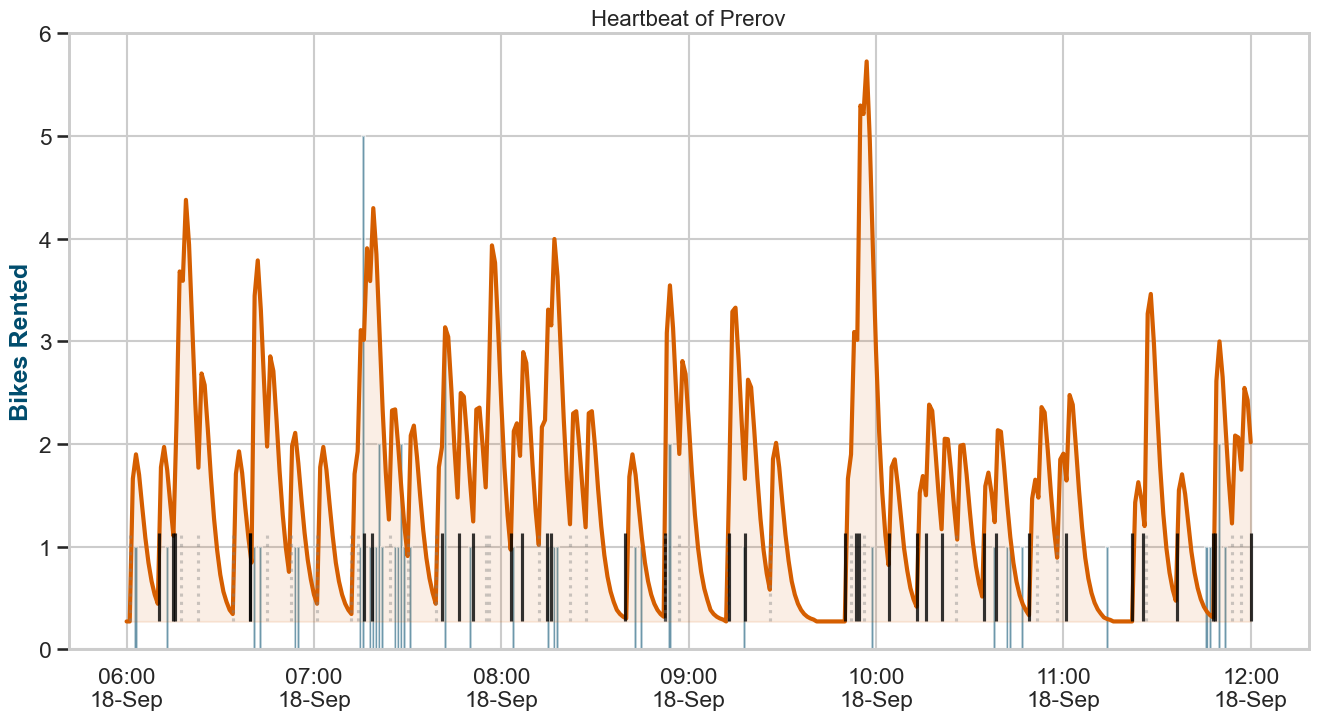

In [8]:
# Try changing the city and dates to find interesting patterns
plot_timeline('Prerov', '2025-09-18 06:00', '2025-09-18 12:00')